# Best trend model report

This notebook is a compact report, not an exploratory sandbox.

**Question.** Which market trend model is best on average across blocked test windows, and how does it behave on several different windows?

**Answer preview.** The best average model from the blocked-CV research is `ema_plus_key + ridge`.
It combines EMA-based trend features with the key-rate block and uses ridge regularization to keep the fit stable under collinearity.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'cashflow' / 'market' / 'trend' / 'trend_research_utils.py').exists():
        ROOT = candidate
        break

if ROOT is None:
    raise RuntimeError('Could not locate repository root from current working directory')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cashflow.market.trend.trend_research_utils import DEFAULT_KEY_RATE_COLUMNS, DEFAULT_TREND_WINDOWS

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

DATA_DIR = ROOT / 'cashflow' / 'market' / 'trend' / 'data'
FIG_DIR = DATA_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

clean_path = ROOT / 'cashflow' / 'market' / 'data' / 'quarterly_market_clean.parquet'
metrics_path = DATA_DIR / 'metrics_by_position.csv'
trend_path = DATA_DIR / 'trend_baselines_by_position.csv'
pred_path = DATA_DIR / 'predictions_by_position.csv'

panel = pd.read_parquet(clean_path).copy()
metrics = pd.read_csv(metrics_path)
trend = pd.read_csv(trend_path)
pred = pd.read_csv(pred_path)

panel['quarter_norm'] = panel['quarter'].astype(str)
panel['quarter_period'] = pd.PeriodIndex(panel['quarter_norm'], freq='Q')
panel['x'] = np.arange(len(panel), dtype=int)
quarter_to_x = dict(zip(panel['quarter_norm'], panel['x']))

feature_sets = {
    'key_rate_only': list(DEFAULT_KEY_RATE_COLUMNS) + ['key_rate_spread_q', 'key_rate_ma_4', 'key_rate_ema_4', 'key_rate_ma_8', 'key_rate_ema_8'],
    'lin_plus_key': [f'lin_{w}' for w in DEFAULT_TREND_WINDOWS] + list(DEFAULT_KEY_RATE_COLUMNS) + ['key_rate_spread_q', 'key_rate_ma_4', 'key_rate_ema_4', 'key_rate_ma_8', 'key_rate_ema_8'],
    'sma_plus_key': [f'sma_{w}' for w in DEFAULT_TREND_WINDOWS] + list(DEFAULT_KEY_RATE_COLUMNS) + ['key_rate_spread_q', 'key_rate_ma_4', 'key_rate_ema_4', 'key_rate_ma_8', 'key_rate_ema_8'],
    'ema_plus_key': [f'ema_{w}' for w in DEFAULT_TREND_WINDOWS] + list(DEFAULT_KEY_RATE_COLUMNS) + ['key_rate_spread_q', 'key_rate_ma_4', 'key_rate_ema_4', 'key_rate_ma_8', 'key_rate_ema_8'],
    'poly_plus_key': [f'poly_{w}' for w in DEFAULT_TREND_WINDOWS] + list(DEFAULT_KEY_RATE_COLUMNS) + ['key_rate_spread_q', 'key_rate_ma_4', 'key_rate_ema_4', 'key_rate_ma_8', 'key_rate_ema_8'],
    'combo_trend_only': [f'{kind}_{w}' for kind in ('lin', 'sma', 'ema', 'poly') for w in DEFAULT_TREND_WINDOWS],
    'combo_trend_plus_key': [f'{kind}_{w}' for kind in ('lin', 'sma', 'ema', 'poly') for w in DEFAULT_TREND_WINDOWS] + list(DEFAULT_KEY_RATE_COLUMNS) + ['key_rate_spread_q', 'key_rate_ma_4', 'key_rate_ema_4', 'key_rate_ma_8', 'key_rate_ema_8'],
}

summary = metrics.groupby(['feature_set', 'model_kind'])[['R2', 'MAE_log', 'RMSE_log']].mean().sort_values(['RMSE_log', 'MAE_log'], ascending=[True, True])
trend_summary = trend.groupby('model_kind')[['R2', 'MAE_log', 'RMSE_log']].mean().sort_values(['RMSE_log', 'MAE_log'], ascending=[True, True])

best_row = summary.reset_index().iloc[0]
best_feature_set = best_row['feature_set']
best_model_kind = best_row['model_kind']
best_feature_cols = feature_sets[best_feature_set]

best_metrics = metrics[(metrics['feature_set'] == best_feature_set) & (metrics['model_kind'] == best_model_kind)].copy()
best_pred = pred[(pred['feature_set'] == best_feature_set) & (pred['model_kind'] == best_model_kind)].copy()
best_pred['x'] = best_pred['quarter_norm'].map(quarter_to_x)
best_pred = best_pred.sort_values(['pos_idx', 'x'])

best_metrics = best_metrics.sort_values('test_start').reset_index(drop=True)
selected_idx = np.unique(np.round(np.linspace(0, len(best_metrics) - 1, 6)).astype(int))
selected_pos = best_metrics.iloc[selected_idx]['pos_idx'].tolist()
selected_meta = best_metrics[best_metrics['pos_idx'].isin(selected_pos)].sort_values('test_start').copy()

print(f'Best average model: {best_feature_set} + {best_model_kind}')
print(f'Feature count: {len(best_feature_cols)}')
print('Feature columns:')
print(best_feature_cols)
print('\nTop model families by average RMSE:')
display(summary.head(10).round(4))
print('\nBest raw trend baselines by average RMSE:')
display(trend_summary.head(10).round(4))
print('\nSelected windows for plots:')
display(selected_meta[['pos_idx', 'test_start', 'test_end', 'RMSE_log', 'MAE_log', 'R2']].round(4))


Best average model: ema_plus_key + ridge
Feature count: 14
Feature columns:
['ema_3', 'ema_6', 'ema_10', 'key_rate_avg_q', 'key_rate_eoq', 'key_rate_min_q', 'key_rate_max_q', 'key_rate_log_return_q', 'key_rate_qoq_change', 'key_rate_spread_q', 'key_rate_ma_4', 'key_rate_ema_4', 'key_rate_ma_8', 'key_rate_ema_8']

Top model families by average RMSE:


R2  MAE_log  RMSE_log
feature_set   model_kind                            
ema_plus_key  ridge      -20.7665   0.2487    0.2913
              elasticnet -19.2360   0.2476    0.2920
              lasso      -21.9081   0.2602    0.3068
baseline      naive      -11.8063   0.2767    0.3111
ema_plus_key  linear     -15.6915   0.2772    0.3377
sma_plus_key  ridge      -26.1740   0.3002    0.3468
              lasso      -27.5011   0.2970    0.3495
key_rate_only linear     -18.1448   0.2707    0.3518
sma_plus_key  elasticnet -27.7109   0.3024    0.3548
key_rate_only ridge      -22.1189   0.3082    0.3648


Best raw trend baselines by average RMSE:


,R2,MAE_log,RMSE_log
model_kind,,,
sma_3,-50.2237,0.2866,0.3405
ema_3,-87.7032,0.3136,0.3751
sma_6,-45.9496,0.3483,0.4093
ema_6,-88.2552,0.3611,0.4290
sma_10,-48.1765,0.4394,0.5020
ema_10,-92.8527,0.4390,0.5084
lin_3,-1240.2783,0.5775,0.6640
poly_6,-1261.7094,0.6732,0.7774
lin_6,-1291.5498,0.7011,0.7919



Selected windows for plots:


,pos_idx,test_start,test_end,RMSE_log,MAE_log,R2
0,0,0,14,0.2001,0.1400,0.1553
2,2,7,21,0.5306,0.4573,-42.9045
4,4,14,28,0.1994,0.1551,-0.2816
5,5,17,31,0.1644,0.1441,0.2168
7,7,24,38,0.1227,0.1065,-0.1592
9,9,31,45,0.2751,0.2342,-2.9822


## 1. Which model won?

The winning specification is `ema_plus_key + ridge`.

What it means:
- trend side: EMA features on the clean market series with windows 3, 6, 10 quarters;
- macro side: key rate block only, plus the small derived key-rate summaries already used in the research notebook;
- estimator: Ridge regression.

Why this one wins:
- it is more stable than raw linear / polynomial trend fits;
- it uses the EMA family, which tracks the recent market slope better than SMA in this dataset;
- Ridge keeps the fit from exploding when the trend and key-rate features are highly collinear.

The research ranking uses mean `RMSE_log` across blocked test windows, with `MAE_log` as a secondary tie-breaker.

,group,feature_set,model_kind,R2,MAE_log,RMSE_log
0,best overall,ema_plus_key,ridge,-20.7665,0.2487,0.2913
1,best trend baseline,sma_3,direct trend,-50.2237,0.2866,0.3405
2,naive baseline,baseline,naive_last_value,-11.8063,0.2767,0.3111


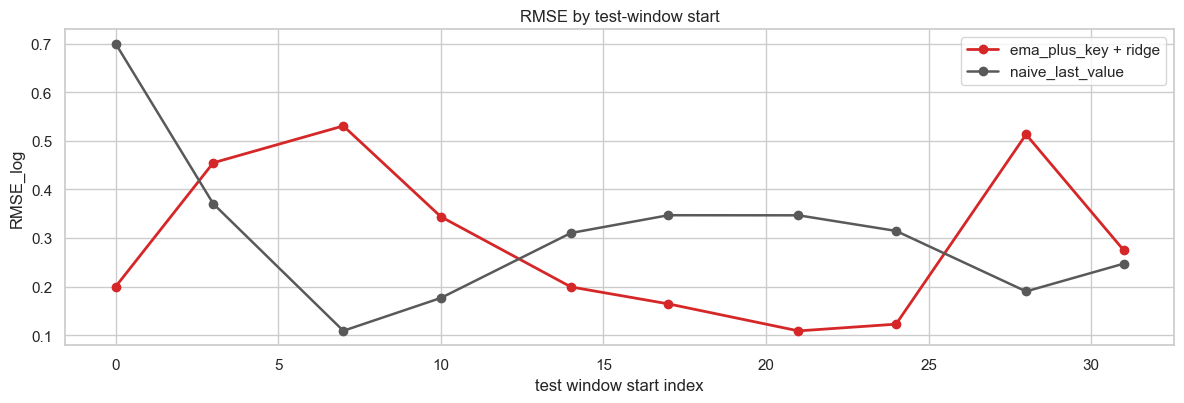

In [2]:
comparison = pd.DataFrame(
    [
        {'group': 'best overall', 'feature_set': best_feature_set, 'model_kind': best_model_kind, **summary.iloc[0].to_dict()},
        {'group': 'best trend baseline', 'feature_set': trend_summary.index[0], 'model_kind': 'direct trend', **trend_summary.iloc[0].to_dict()},
        {'group': 'naive baseline', 'feature_set': 'baseline', 'model_kind': 'naive_last_value', **metrics[(metrics['feature_set'] == 'baseline') & (metrics['model_kind'] == 'naive')][['R2', 'MAE_log', 'RMSE_log']].mean().to_dict()},
    ]
)
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(12, 4.2))
wide = best_metrics[['pos_idx', 'test_start', 'RMSE_log', 'MAE_log']].copy().sort_values('test_start')
ax.plot(wide['test_start'], wide['RMSE_log'], color='#d62728', lw=2.0, marker='o', label=f'{best_feature_set} + {best_model_kind}')
naive_wide = metrics[(metrics['feature_set'] == 'baseline') & (metrics['model_kind'] == 'naive')][['test_start', 'RMSE_log']].sort_values('test_start')
ax.plot(naive_wide['test_start'], naive_wide['RMSE_log'], color='0.35', lw=1.8, marker='o', label='naive_last_value')
ax.set_title('RMSE by test-window start')
ax.set_xlabel('test window start index')
ax.set_ylabel('RMSE_log')
ax.legend(frameon=True)
fig.tight_layout()
plt.show()


## 2. Window plots

Below are six representative blocked test windows for the best model.

The black line is the full clean market series.
The red line is the best model's prediction inside the held-out window.
The yellow band marks the test window itself.

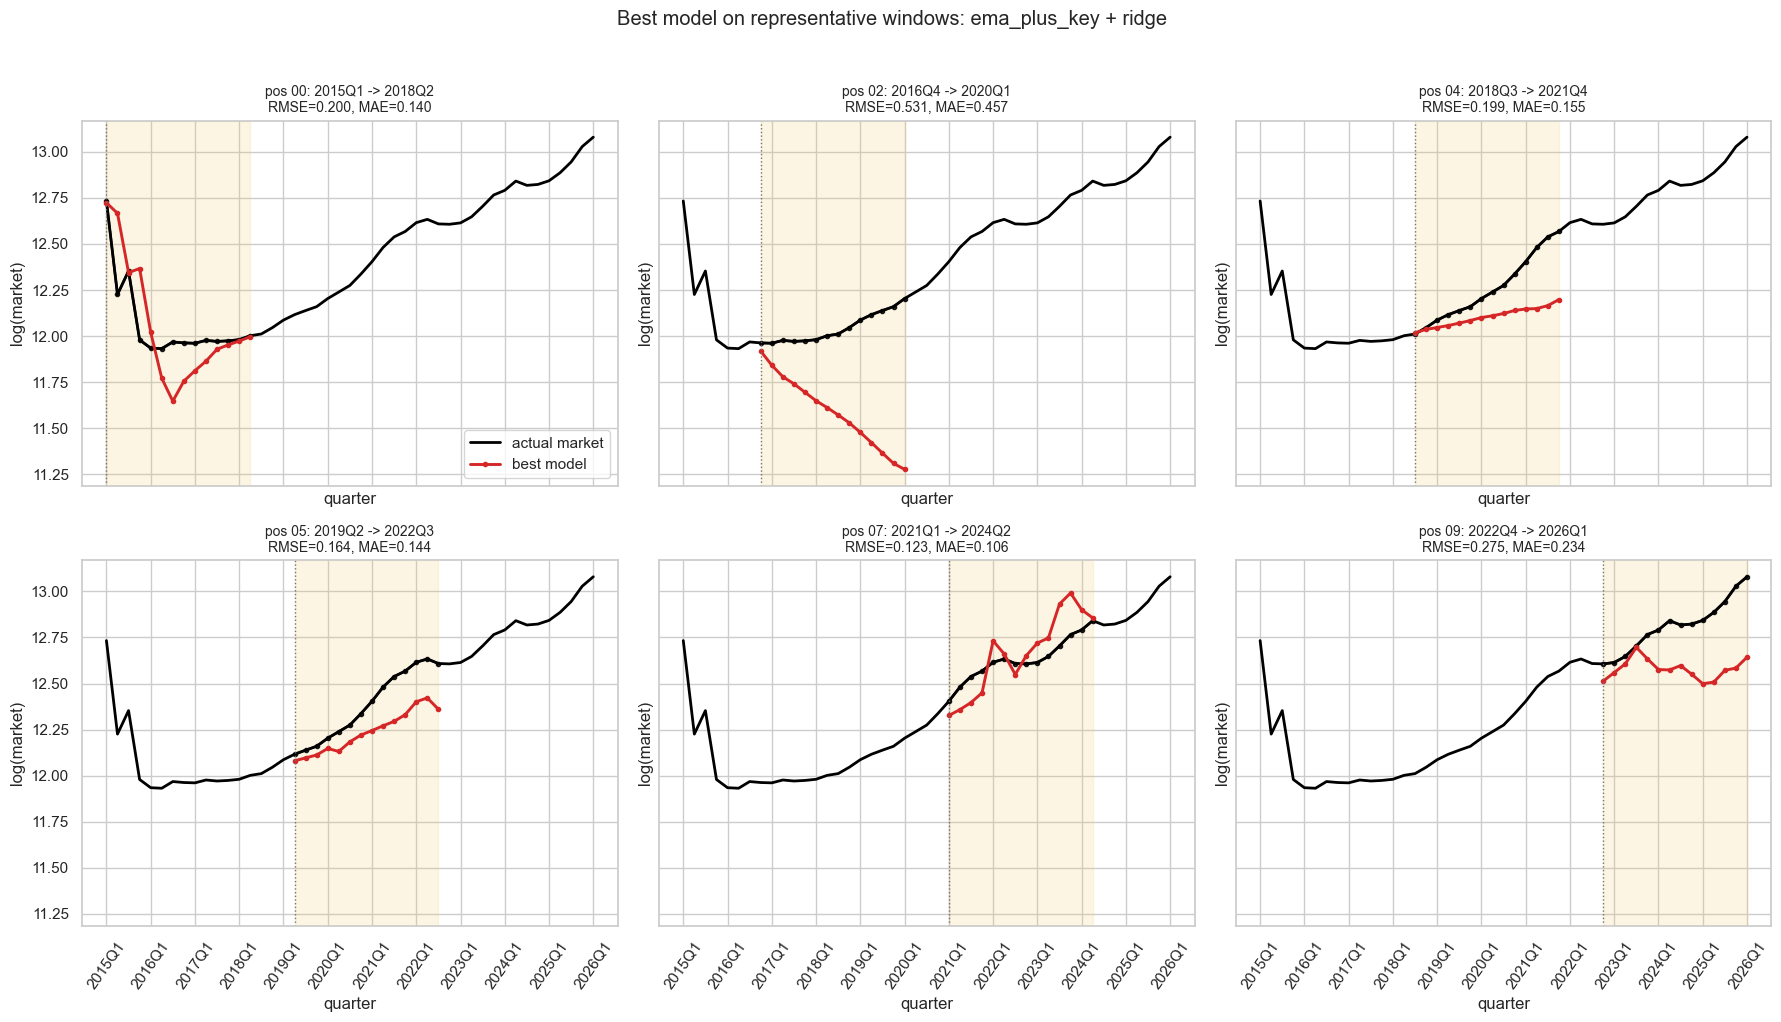

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.ravel()
y_full = panel['market_log_level_q'].to_numpy(dtype=float)
for ax, pos_idx in zip(axes, selected_pos):
    win = best_pred[best_pred['pos_idx'] == pos_idx].copy().sort_values('x')
    meta = best_metrics[best_metrics['pos_idx'] == pos_idx].iloc[0]
    start_x = int(win['x'].iloc[0])
    end_x = int(win['x'].iloc[-1])
    ax.plot(panel['x'], y_full, color='black', lw=2.0, label='actual market')
    ax.axvspan(start_x, end_x, color='#f3c969', alpha=0.18)
    ax.plot(win['x'], win['y_true'], color='black', lw=1.8, marker='o', ms=3.0, alpha=0.85)
    ax.plot(win['x'], win['y_pred'], color='#d62728', lw=2.1, marker='o', ms=3.0, label='best model')
    ax.axvline(start_x, color='0.45', ls=':', lw=1.0)
    title = f"pos {int(meta['pos_idx']):02d}: {panel.loc[start_x, 'quarter_norm']} -> {panel.loc[end_x, 'quarter_norm']}\nRMSE={meta['RMSE_log']:.3f}, MAE={meta['MAE_log']:.3f}"
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=55)

for ax in axes:
    ax.set_xlabel('quarter')
    ax.set_ylabel('log(market)')

xticks = panel['x'][::4]
xticklabels = panel['quarter_norm'][::4]
for ax in axes:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=55)

axes[0].legend(loc='best', frameon=True)
fig.suptitle(f'Best model on representative windows: {best_feature_set} + {best_model_kind}', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'best_trend_model_windows.png', dpi=160, bbox_inches='tight')
plt.show()


## 3. Selected windows table

The grid above uses windows spread across the full timeline, so you can see how the same model behaves when the market path is calm, turning, or sharply rising.

In [4]:
selected_windows = selected_meta[['pos_idx', 'test_start', 'test_end', 'RMSE_log', 'MAE_log', 'R2']].copy()
selected_windows['start_quarter'] = panel.loc[selected_windows['test_start'], 'quarter_norm'].to_numpy()
selected_windows['end_quarter'] = panel.loc[selected_windows['test_end'] - 1, 'quarter_norm'].to_numpy()
selected_windows = selected_windows[['pos_idx', 'start_quarter', 'end_quarter', 'RMSE_log', 'MAE_log', 'R2']]
display(selected_windows.round(4))


,pos_idx,start_quarter,end_quarter,RMSE_log,MAE_log,R2
0,0,2015Q1,2018Q2,0.2001,0.1400,0.1553
2,2,2016Q4,2020Q1,0.5306,0.4573,-42.9045
4,4,2018Q3,2021Q4,0.1994,0.1551,-0.2816
5,5,2019Q2,2022Q3,0.1644,0.1441,0.2168
7,7,2021Q1,2024Q2,0.1227,0.1065,-0.1592
9,9,2022Q4,2026Q1,0.2751,0.2342,-2.9822


## Takeaway

If the goal is a practical trend model for this market series, the safest default is:

1. Use `ema_plus_key + ridge` as the main specification.
2. Judge it by blocked-window mean `RMSE_log`, not by a single split.
3. Expect variability across windows: some periods are easy, some are much noisier.
4. Keep the plot book small and focused on representative windows instead of overfitting the report itself.